In [ ]:
#!/bin/bash
!curl -L -o insurance-product-purchase-prediction.zip\
  https://www.kaggle.com/api/v1/datasets/download/akhilups/insurance-product-purchase-prediction

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 7009k  100 7009k    0     0  8817k      0 --:--:-- --:--:-- --:--:-- 14.7M


In [ ]:
!unzip /content/insurance-product-purchase-prediction.zip

Archive:  /content/insurance-product-purchase-prediction.zip
  inflating: train.csv               


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder,StandardScaler,LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
from xgboost import XGBRegressor



In [ ]:
df = pd.read_csv('/content/train.csv')
df

,customer_ID,shopping_pt,record_type,day,time,state,location,group_size,homeowner,car_age,...,C_previous,duration_previous,A,B,C,D,E,F,G,cost
0,10000000,1,0,0,08:35,IN,10001,2,0,2,...,1.0,2.0,1,0,2,2,1,2,2,633
1,10000000,2,0,0,08:38,IN,10001,2,0,2,...,1.0,2.0,1,0,2,2,1,2,1,630
2,10000000,3,0,0,08:38,IN,10001,2,0,2,...,1.0,2.0,1,0,2,2,1,2,1,630
3,10000000,4,0,0,08:39,IN,10001,2,0,2,...,1.0,2.0,1,0,2,2,1,2,1,630
4,10000000,5,0,0,11:55,IN,10001,2,0,2,...,1.0,2.0,1,0,2,2,1,2,1,630
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
665244,10152724,2,0,3,13:43,KY,10204,1,1,1,...,1.0,4.0,1,0,2,3,0,2,2,677
665245,10152724,3,0,3,13:43,KY,10204,1,1,1,...,1.0,4.0,1,0,2,3,0,2,2,677
665246,10152724,4,0,3,13:44,KY,10204,1,1,1,...,1.0,4.0,1,0,2,3,0,2,2,677
665247,10152724,5,0,3,13:46,KY,10204,1,1,1,...,1.0,4.0,1,0,2,3,0,2,2,685


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 665249 entries, 0 to 665248
Data columns (total 25 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   customer_ID        665249 non-null  int64  
 1   shopping_pt        665249 non-null  int64  
 2   record_type        665249 non-null  int64  
 3   day                665249 non-null  int64  
 4   time               665249 non-null  object 
 5   state              665249 non-null  object 
 6   location           665249 non-null  int64  
 7   group_size         665249 non-null  int64  
 8   homeowner          665249 non-null  int64  
 9   car_age            665249 non-null  int64  
 10  car_value          663718 non-null  object 
 11  risk_factor        424831 non-null  float64
 12  age_oldest         665249 non-null  int64  
 13  age_youngest       665249 non-null  int64  
 14  married_couple     665249 non-null  int64  
 15  C_previous         646538 non-null  float64
 16  du

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
customer_ID,665249.0,1.007655e+07,44049.778593,10000000.0,10038523.0,10076403.0,10114696.0,10152724.0
shopping_pt,665249.0,4.219966e+00,2.394369,1.0,2.0,4.0,6.0,13.0
record_type,665249.0,1.458236e-01,0.352930,0.0,0.0,0.0,0.0,1.0
day,665249.0,1.969429e+00,1.453470,0.0,1.0,2.0,3.0,6.0
location,665249.0,1.227154e+04,1564.789415,10001.0,10936.0,12027.0,13426.0,16580.0
group_size,665249.0,1.234784e+00,0.461036,1.0,1.0,1.0,1.0,4.0
homeowner,665249.0,5.362293e-01,0.498686,0.0,0.0,1.0,1.0,1.0
car_age,665249.0,8.139437e+00,5.764598,0.0,3.0,7.0,12.0,85.0
risk_factor,424831.0,2.563996e+00,1.111584,1.0,2.0,3.0,4.0,4.0
age_oldest,665249.0,4.499240e+01,17.403440,18.0,28.0,44.0,60.0,75.0


In [ ]:
df = df[df['record_type'] == 1].copy()

In [ ]:
df.drop(['record_type','customer_ID'],axis = 1,inplace = True)

In [ ]:
df.drop(['shopping_pt'],axis = 1,inplace = True)

In [ ]:
df.isnull().sum()

,0
day,0
time,0
state,0
location,0
group_size,0
homeowner,0
car_age,0
car_value,0
risk_factor,34346
age_oldest,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 97009 entries, 8 to 665248
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   day                97009 non-null  int64  
 1   time               97009 non-null  object 
 2   state              97009 non-null  object 
 3   location           97009 non-null  int64  
 4   group_size         97009 non-null  int64  
 5   homeowner          97009 non-null  int64  
 6   car_age            97009 non-null  int64  
 7   car_value          97009 non-null  object 
 8   risk_factor        62663 non-null  float64
 9   age_oldest         97009 non-null  int64  
 10  age_youngest       97009 non-null  int64  
 11  married_couple     97009 non-null  int64  
 12  C_previous         96173 non-null  float64
 13  duration_previous  96173 non-null  float64
 14  A                  97009 non-null  int64  
 15  B                  97009 non-null  int64  
 16  C                  97009 n

In [ ]:
cat_cols = [col for col in df.columns if df[col].dtype in ['bool','object','category']]
print(cat_cols)
num_cols = [col for col in df.columns if df[col].dtype in ['int64','float64']]
print(num_cols)

['time', 'state', 'car_value']
['day', 'location', 'group_size', 'homeowner', 'car_age', 'risk_factor', 'age_oldest', 'age_youngest', 'married_couple', 'C_previous', 'duration_previous', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'cost']


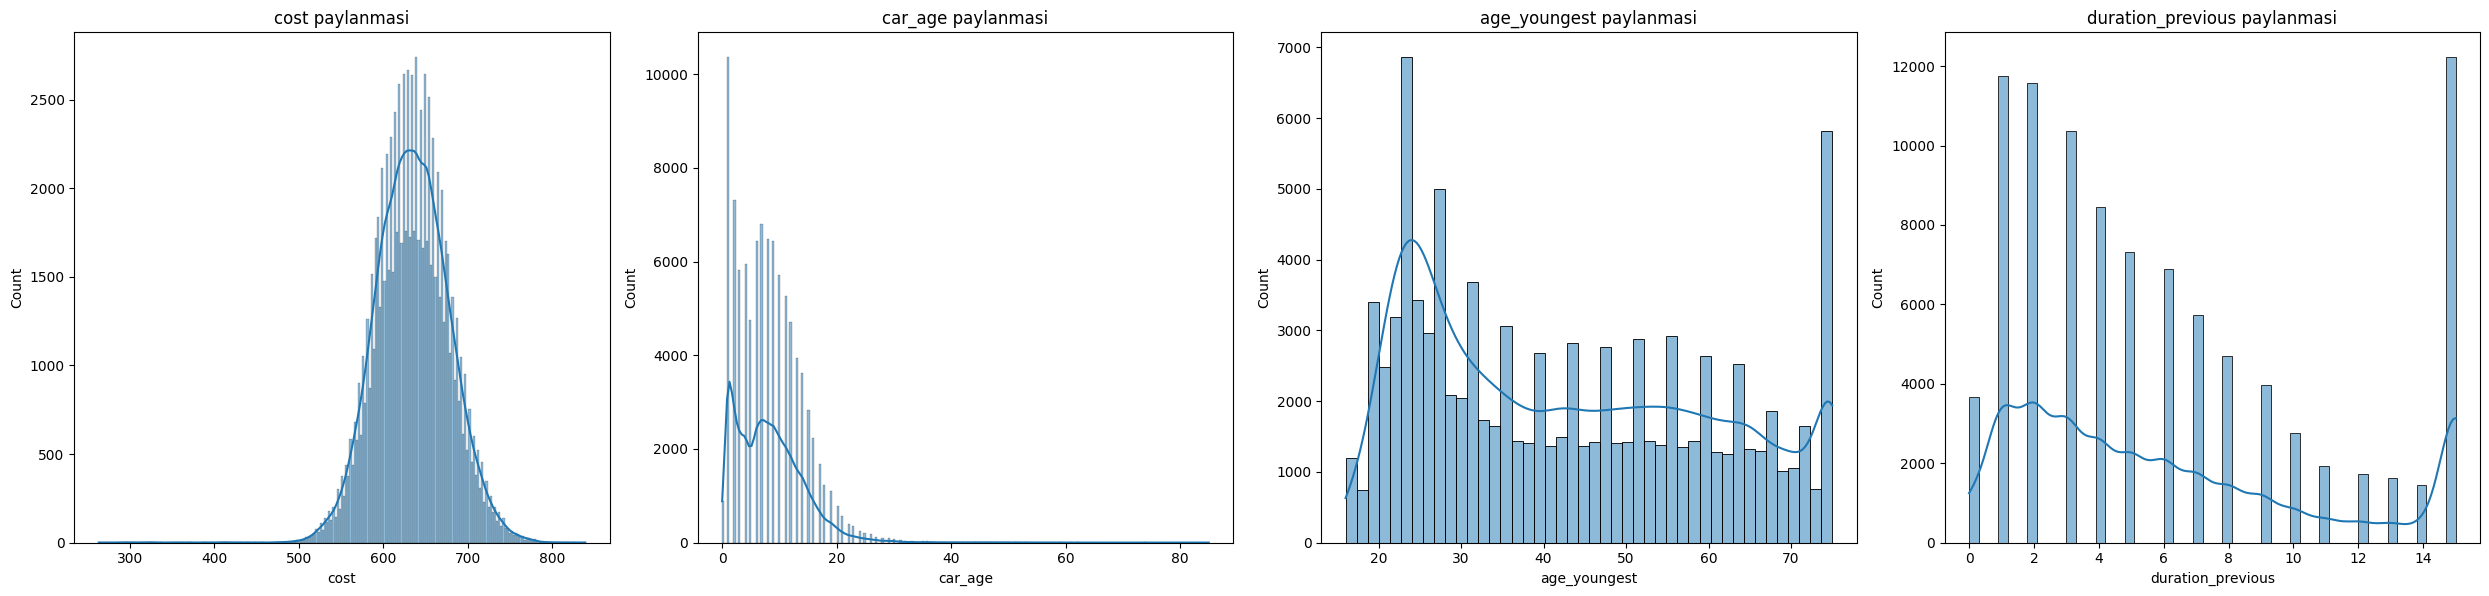

In [ ]:
k = ['cost','car_age','age_youngest','duration_previous']
plt.figure(figsize = (25,17))
for i,col in enumerate(k,1):
  plt.subplot(3,4,i)
  sns.histplot(df[col],kde = True)
  plt.title(f'{col} paylanmasi')
plt.tight_layout()
plt.show()


In [ ]:
df['age_oldest'].corr(df['age_youngest'])

np.float64(0.9105129523732617)

In [ ]:
df.drop('age_oldest', axis=1, inplace=True)

In [ ]:
binary_cols = [col for col in df.columns if df[col].nunique() == 2]
binary_cols

['homeowner', 'married_couple', 'B', 'E']

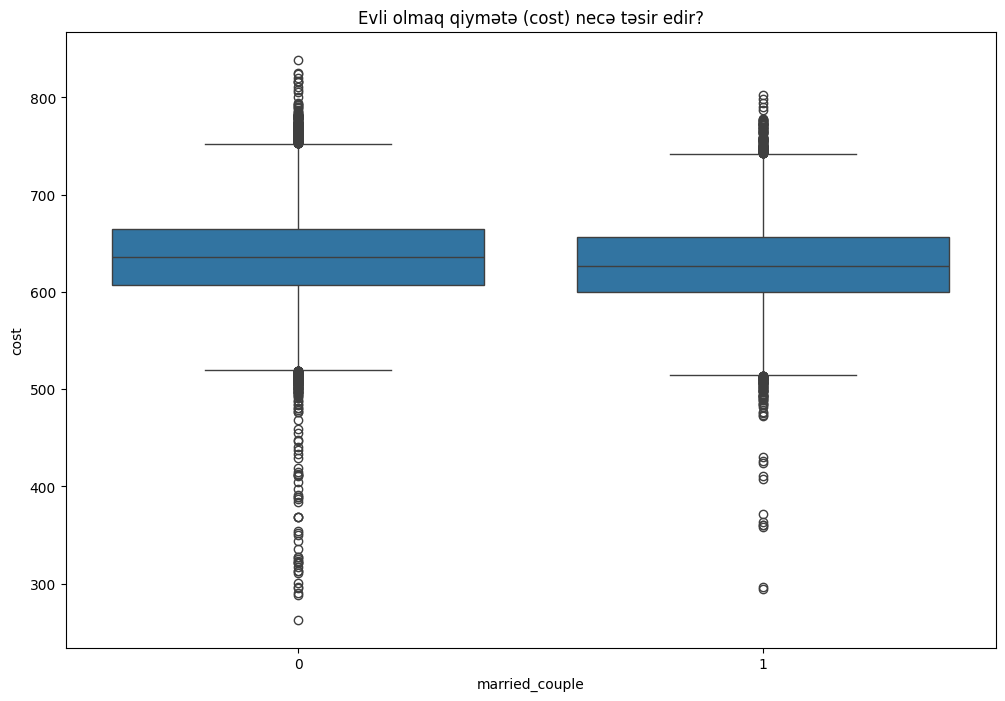

In [ ]:
plt.figure(figsize = (12,8))
sns.boxplot(x = 'married_couple',y = 'cost',data = df)
plt.title('Evli olmaq qiymətə (cost) necə təsir edir?')
plt.show()
#Evli cütlüklər orta hesabla subaylara nisbətən daha az sığorta haqqı ödəyirlər.

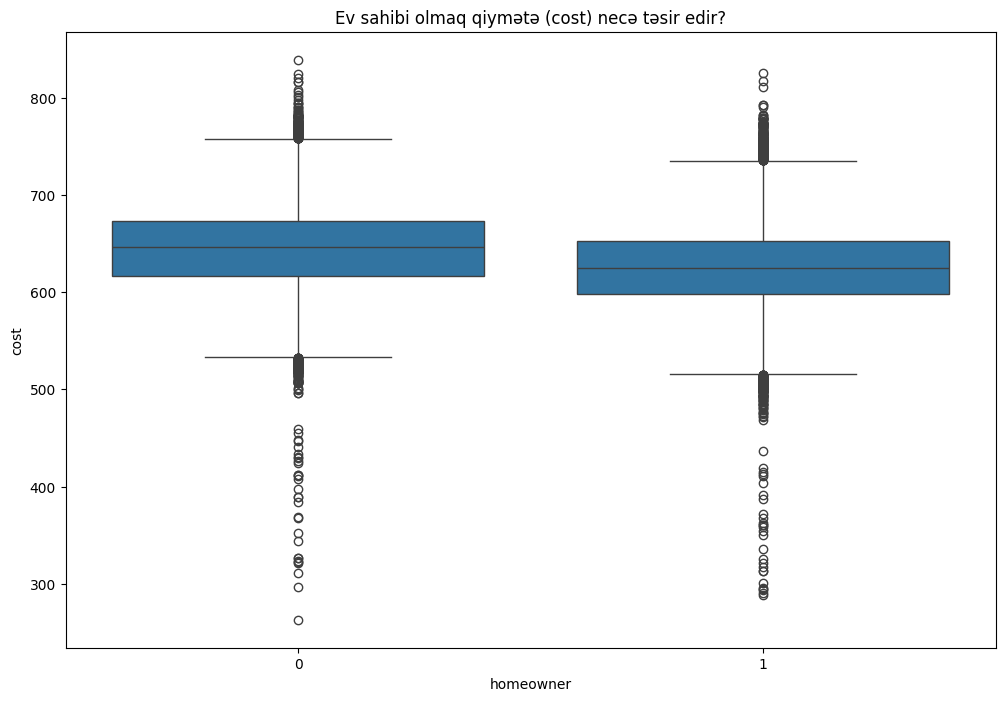

In [ ]:
plt.figure(figsize = (12,8))
sns.boxplot(x = 'homeowner',y = 'cost',data = df)
plt.title('Ev sahibi olmaq qiymətə (cost) necə təsir edir?')
plt.show()

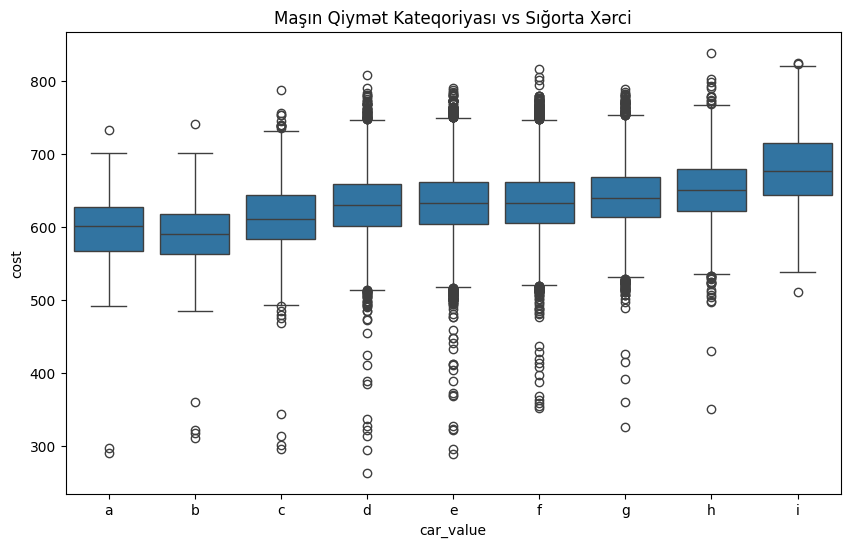

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='car_value', y='cost', data=df, order=sorted(df['car_value'].unique()))
plt.title('Maşın Qiymət Kateqoriyası vs Sığorta Xərci')
plt.show()

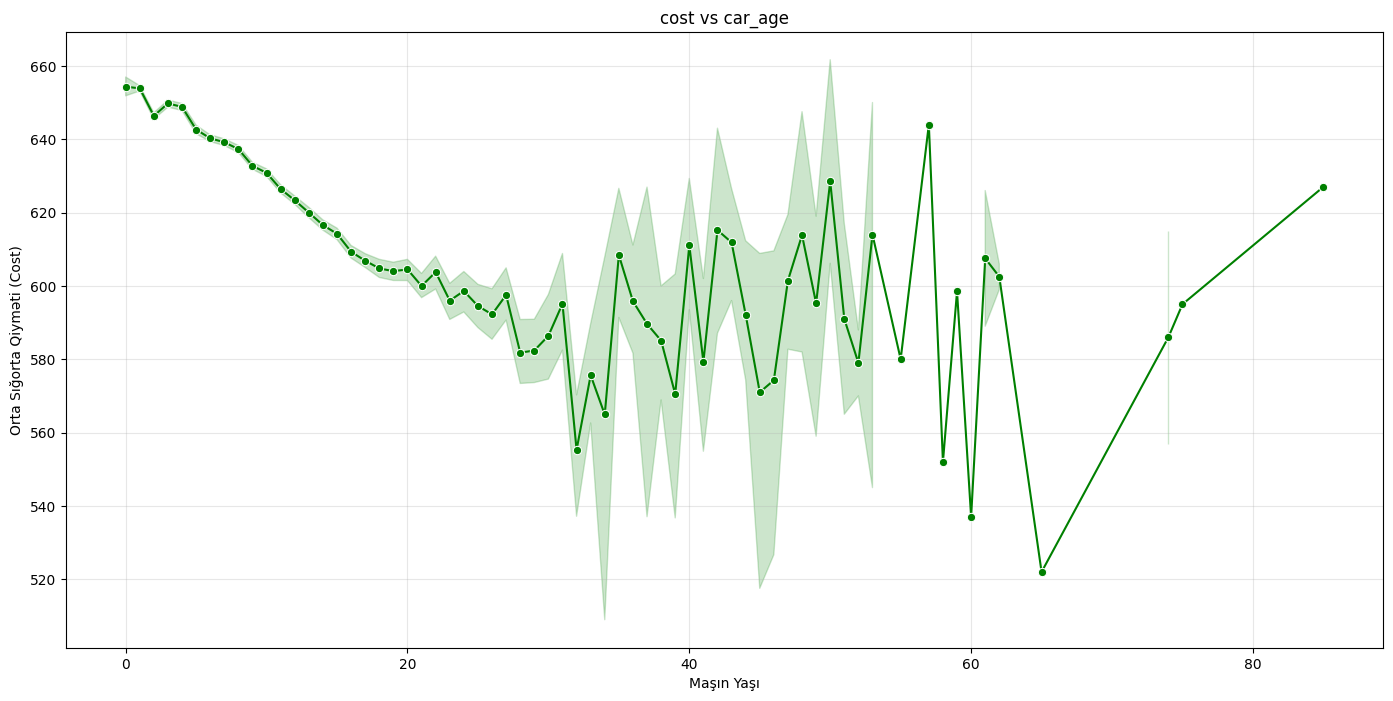

In [ ]:
plt.figure(figsize= (17,8))
sns.lineplot(data = df,x = 'car_age',y = 'cost',marker = 'o',color = 'green')
plt.title('cost vs car_age')
plt.xlabel('Maşın Yaşı')
plt.ylabel('Orta Sığorta Qiyməti (Cost)')
plt.grid(True, alpha=0.3)

plt.show()
#Təzə maşın bahadır,Köhnəldikcə ucuzlaşır,60 yaşdan sonra qeyri-müəyyənlik

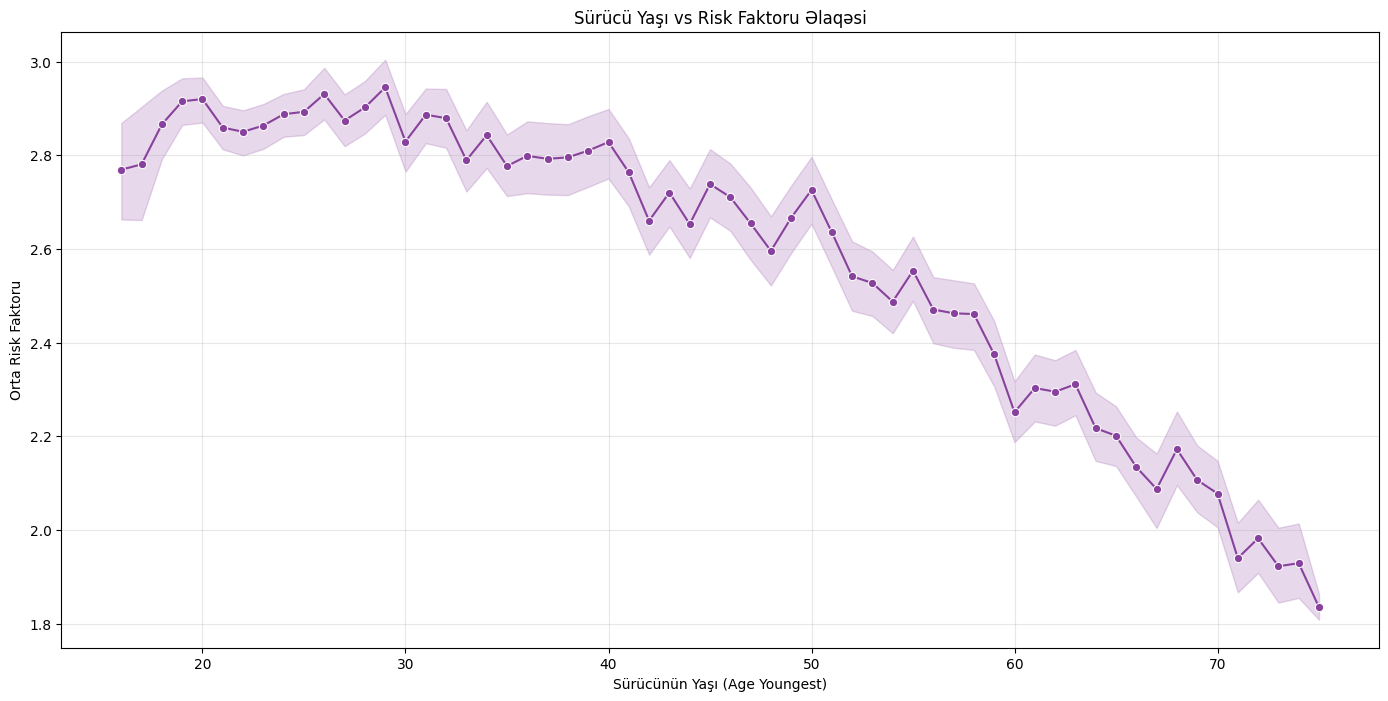

In [ ]:
plt.figure(figsize = (17,8))
sns.lineplot(data = df,x = 'age_youngest',y = 'risk_factor',marker = 'o',color = '#88419d')
plt.title('Sürücü Yaşı vs Risk Faktoru Əlaqəsi')
plt.xlabel('Sürücünün Yaşı (Age Youngest)')
plt.ylabel('Orta Risk Faktoru')
plt.grid(True, alpha=0.3)
plt.show()
#Gənclər daha risklidir,Yaş artdıqca risk azalır

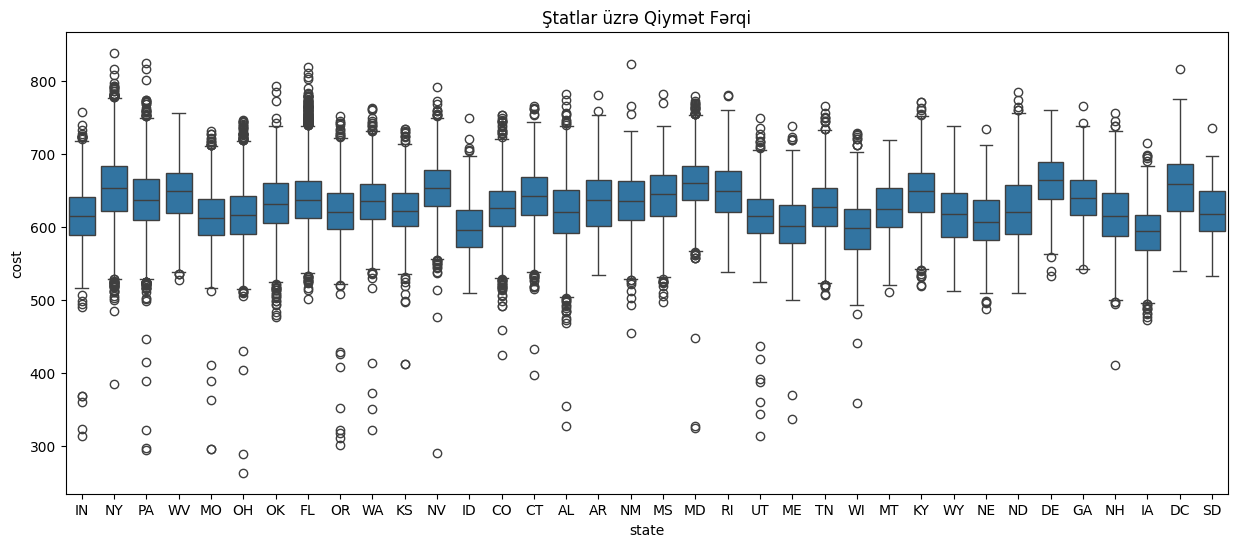

In [ ]:

plt.figure(figsize=(15,6))
sns.boxplot(x='state', y='cost', data=df)
plt.title('Ştatlar üzrə Qiymət Fərqi')
plt.show()
#

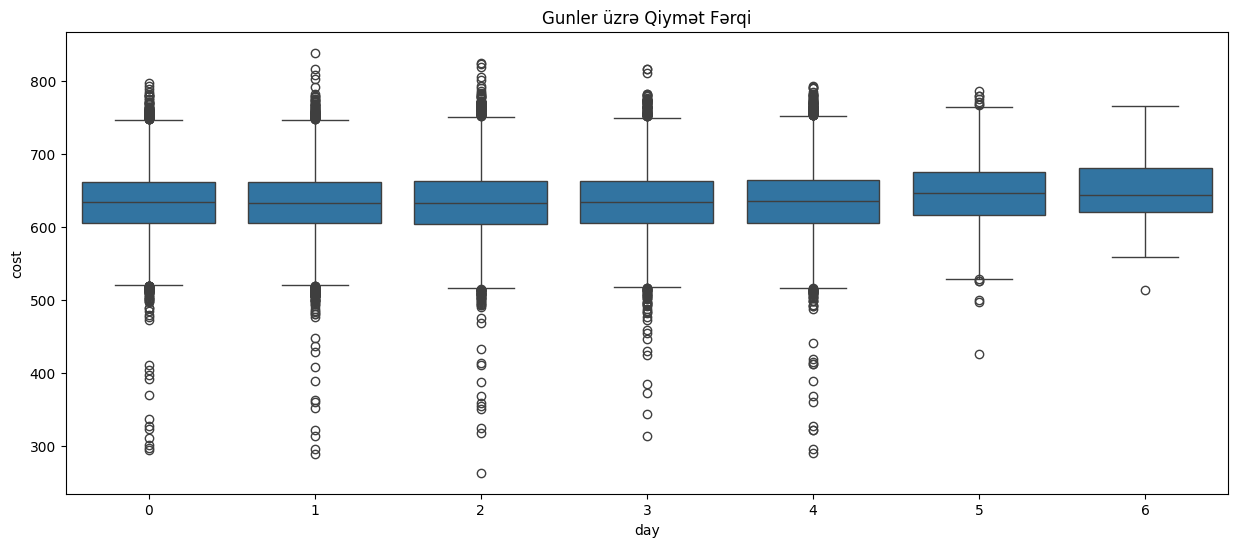

In [ ]:
plt.figure(figsize=(15,6))
sns.boxplot(x='day', y='cost', data=df)
plt.title('Gunler üzrə Qiymət Fərqi')
plt.show()
#Eynilik

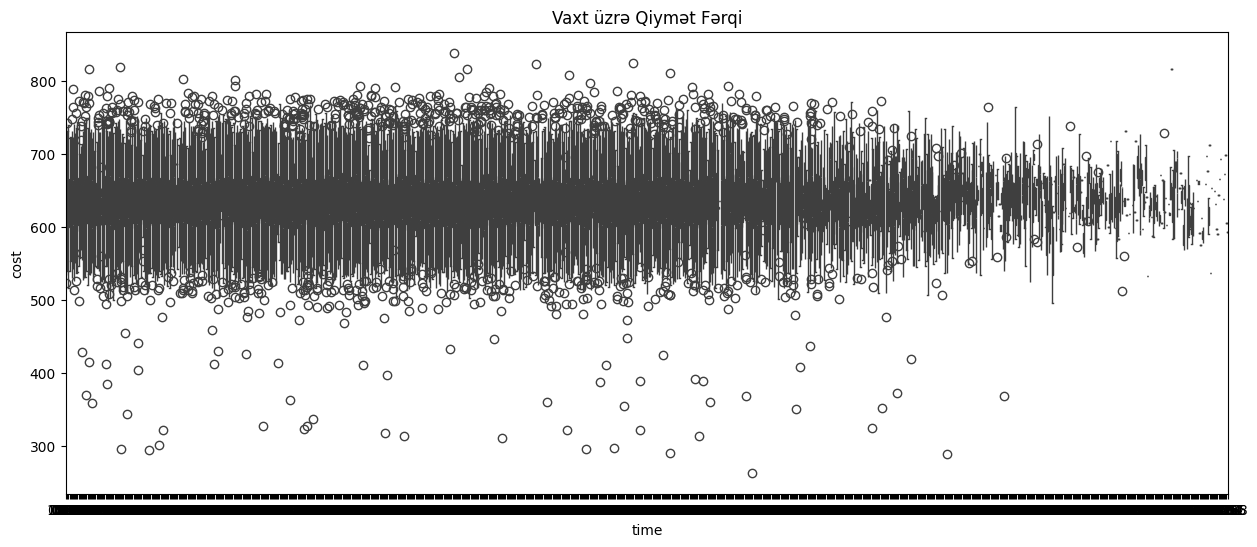

In [ ]:
plt.figure(figsize=(15,6))
sns.boxplot(x='time', y='cost', data=df)
plt.title('Vaxt üzrə Qiymət Fərqi')
plt.show()
#Həddindən çox dağınıqlıq:

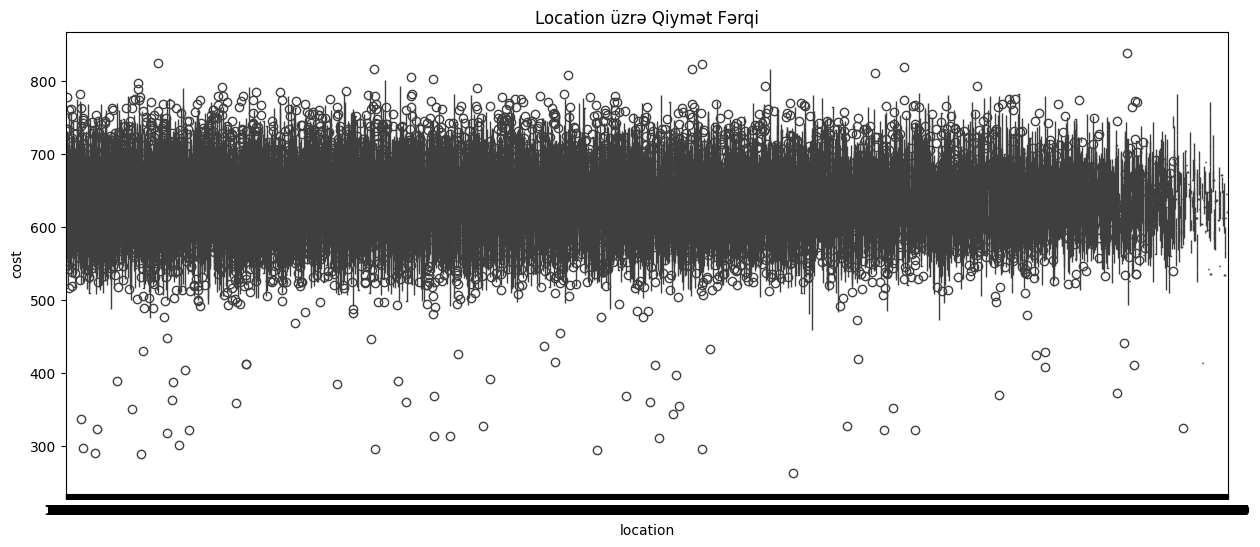

In [ ]:
plt.figure(figsize=(15,6))
sns.boxplot(x='location', y='cost', data=df)
plt.title('Location üzrə Qiymət Fərqi')
plt.show()

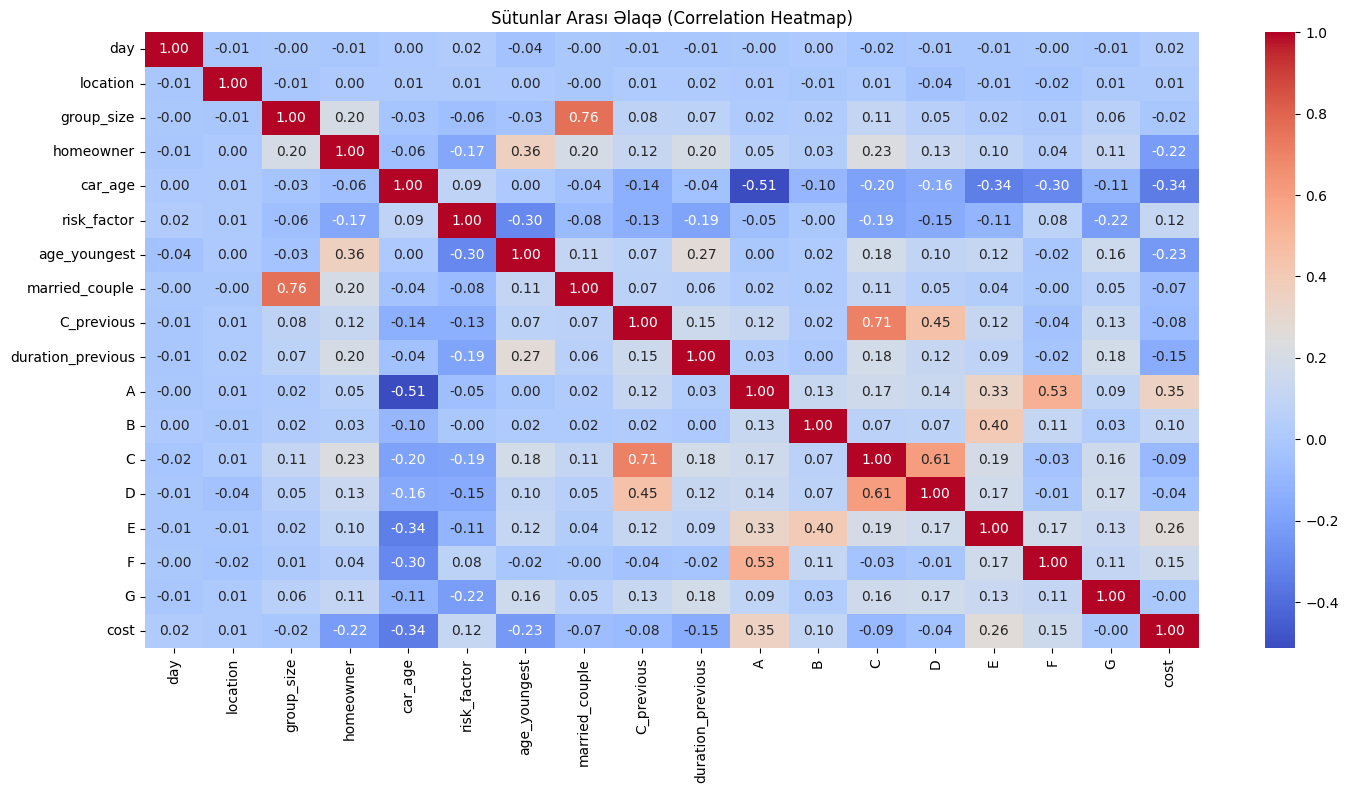

In [ ]:
plt.figure(figsize = (17,8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Sütunlar Arası Əlaqə (Correlation Heatmap)')
plt.show()

In [ ]:
df.drop(['C_previous','married_couple','location','time','day'],axis = 1,inplace = True)

In [ ]:
df.isnull().sum()

,0
state,0
group_size,0
homeowner,0
car_age,0
car_value,0
risk_factor,34346
age_youngest,0
duration_previous,836
A,0
B,0


/tmp/ipykernel_14766/1974932439.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='car_value', palette='viridis')


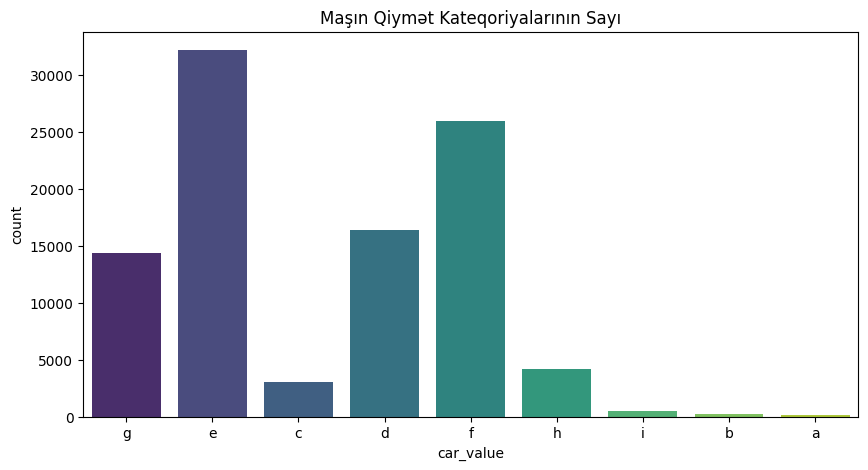

In [ ]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='car_value', palette='viridis')
plt.title('Maşın Qiymət Kateqoriyalarının Sayı')
plt.show()

In [ ]:
def find_outliner(df,cols):
  outliners = []
  for col in cols:
      Q1 = df[col].quantile(0.25)
      Q3 = df[col].quantile(0.75)

      IQR = Q3 - Q1
      low_bound =  Q1 - 1.5 * IQR
      upper_bound = Q3 + 1.5 * IQR
      if ((df[col] > upper_bound) | (df[col] < low_bound)).any():
        outliners.append(col)
  return outliners


In [ ]:
target_cols = [ 'car_age', 'age_youngest', 'duration_previous','risk_factor', 'group_size']
outlier_list = find_outliner(df, target_cols)

In [ ]:
for col in outlier_list:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    low = Q1 - 1.5 * IQR
    high = Q3 + 1.5 * IQR

    # Limitləri tətbiq edirik
    df[col] = df[col].clip(lower=low, upper=high)

In [ ]:
X = df.drop(['cost'],axis = 1)
Y = df['cost']

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [ ]:
num_features = X_train.select_dtypes(include = [np.number]).columns
cat_features = X_train.select_dtypes(exclude =  [np.number]).columns
print("Numeric:",num_features)
print("Cat_cols:" ,cat_features)

Numeric: Index(['group_size', 'homeowner', 'car_age', 'risk_factor', 'age_youngest',
       'duration_previous', 'A', 'B', 'C', 'D', 'E', 'F', 'G'],
      dtype='object')
Cat_cols: Index(['state', 'car_value'], dtype='object')


In [ ]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', sparse_output=False))
])

preprocessing = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
], remainder='passthrough')

In [ ]:
lr = LinearRegression()
lr_model = Pipeline([
    ('preprocessing',preprocessing),
    ('regressor',lr)
])
lr_model.fit(X_train,Y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['group_size', 'homeowner', 'car_age', 'risk_factor', 'age_youngest',
       'duration_previous', 'A', 'B', 'C', 'D', 'E', 'F', 'G'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 sparse_output=False))]),
                                                  Index(['state', 'car_value'], dtype='object'))])),
                ('regressor', LinearRegression())])

In [ ]:
Y_pred = lr_model.predict(X_test)

print("R2 Score:", r2_score(Y_test, Y_pred))
print("RMSE:", np.sqrt(mean_squared_error(Y_test, Y_pred)))
print("MAE:", mean_absolute_error(Y_test, Y_pred))

R2 Score: 0.4473969292740313
RMSE: 32.110988696042504
MAE: 25.148617602387045


In [ ]:
rf = RandomForestRegressor(n_estimators=300, random_state=42,max_depth=20,
    min_samples_leaf=2,
    min_samples_split=5,max_features = 'sqrt')
rf_model = Pipeline([
    ('preprocessing', preprocessing),
    ('regressor', rf)
])
rf_model.fit(X_train, Y_train)


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['group_size', 'homeowner', 'car_age', 'risk_factor', 'age_youngest',
       'duration_previous', 'A', 'B', 'C', 'D', 'E', 'F', 'G'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 sparse_output=False))]),
                                                  Index(['state', 'car_value'], dtype='object'))])),
                ('regressor',
                 RandomForestRegressor(max_depth=20, max_features='sqrt',
                                       min_samples_leaf=2, min_samples_split=5,
                                       n_estimators=300, random_state=42))])

In [ ]:
Y_pred_rf = rf_model.predict(X_test)

print("R2 Score:", r2_score(Y_test, Y_pred_rf))
print("MSE:", np.sqrt(mean_squared_error(Y_test, Y_pred_rf)))
print("MAE:", mean_absolute_error(Y_test, Y_pred_rf))

R2 Score: 0.5388360483290734
MSE: 29.334230938484584
MAE: 22.748254060729963


In [ ]:

xgb = XGBRegressor(
    n_estimators=300,
    max_depth=6,

    learning_rate = 0.1,
    random_state=42
)
xgb_model = Pipeline([
    ('preprocessing', preprocessing),
    ('regressor', xgb)
])
xgb_model.fit(X_train, Y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['group_size', 'homeowner', 'car_age', 'risk_factor', 'age_youngest',
       'duration_previous', 'A', 'B', 'C', 'D', 'E', 'F', 'G'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('i...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.1,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=6, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=300, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [ ]:
Y_pred_xgb = xgb_model.predict(X_test)

print("R2 Score:", r2_score(Y_test, Y_pred_xgb))
print("MSE:", np.sqrt(mean_squared_error(Y_test, Y_pred_xgb)))
print("MAE:", mean_absolute_error(Y_test, Y_pred_xgb))

R2 Score: 0.5961953997612
MSE: 27.44938857434658
MAE: 21.099119186401367


In [ ]:
print("Train R2:", r2_score(Y_train, xgb_model.predict(X_train)))
print("Test R2:", r2_score(Y_test, Y_pred_xgb))

Train R2: 0.6527414321899414
Test R2: 0.5961953997612


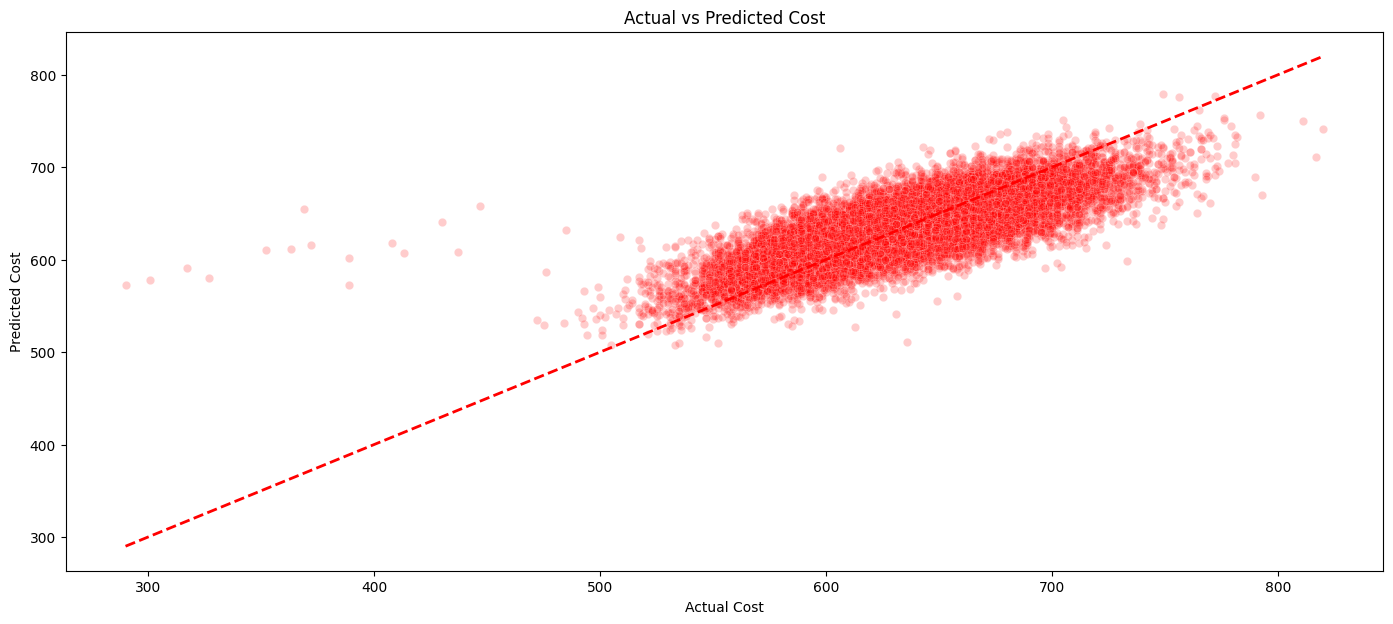

In [ ]:
plt.figure(figsize = (17,7))
sns.scatterplot(x=Y_test, y=Y_pred_xgb, alpha = 0.2,color = 'red')
plt.plot([Y_test.min(),Y_test.max()],[Y_test.min(),Y_test.max()],'r--',lw = 2)
plt.xlabel('Actual Cost')
plt.ylabel('Predicted Cost')
plt.title('Actual vs Predicted Cost')
plt.show()

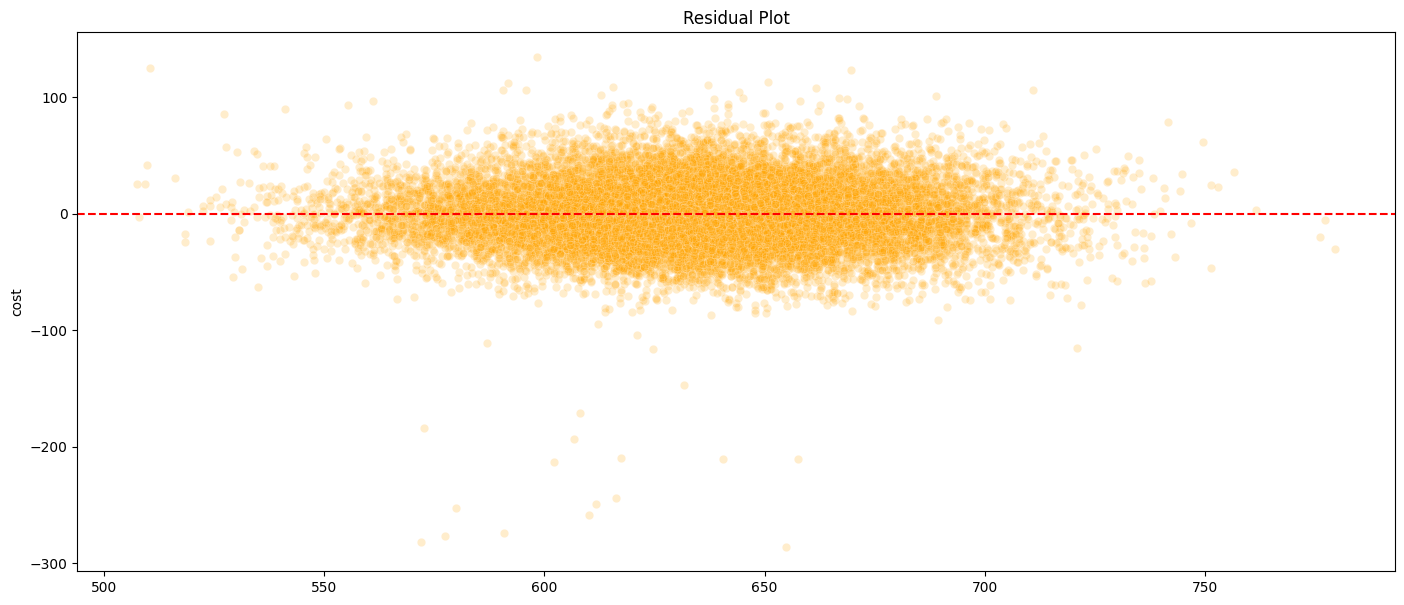

In [ ]:
plt.figure(figsize = (17,7))
sns.scatterplot(x=Y_pred_xgb, y=Y_test - Y_pred_xgb, alpha = 0.2,color = 'orange')

plt.axhline(y = 0,color = 'red',linestyle = '--')
plt.title('Residual Plot')
plt.show()

<BarContainer object of 56 artists>

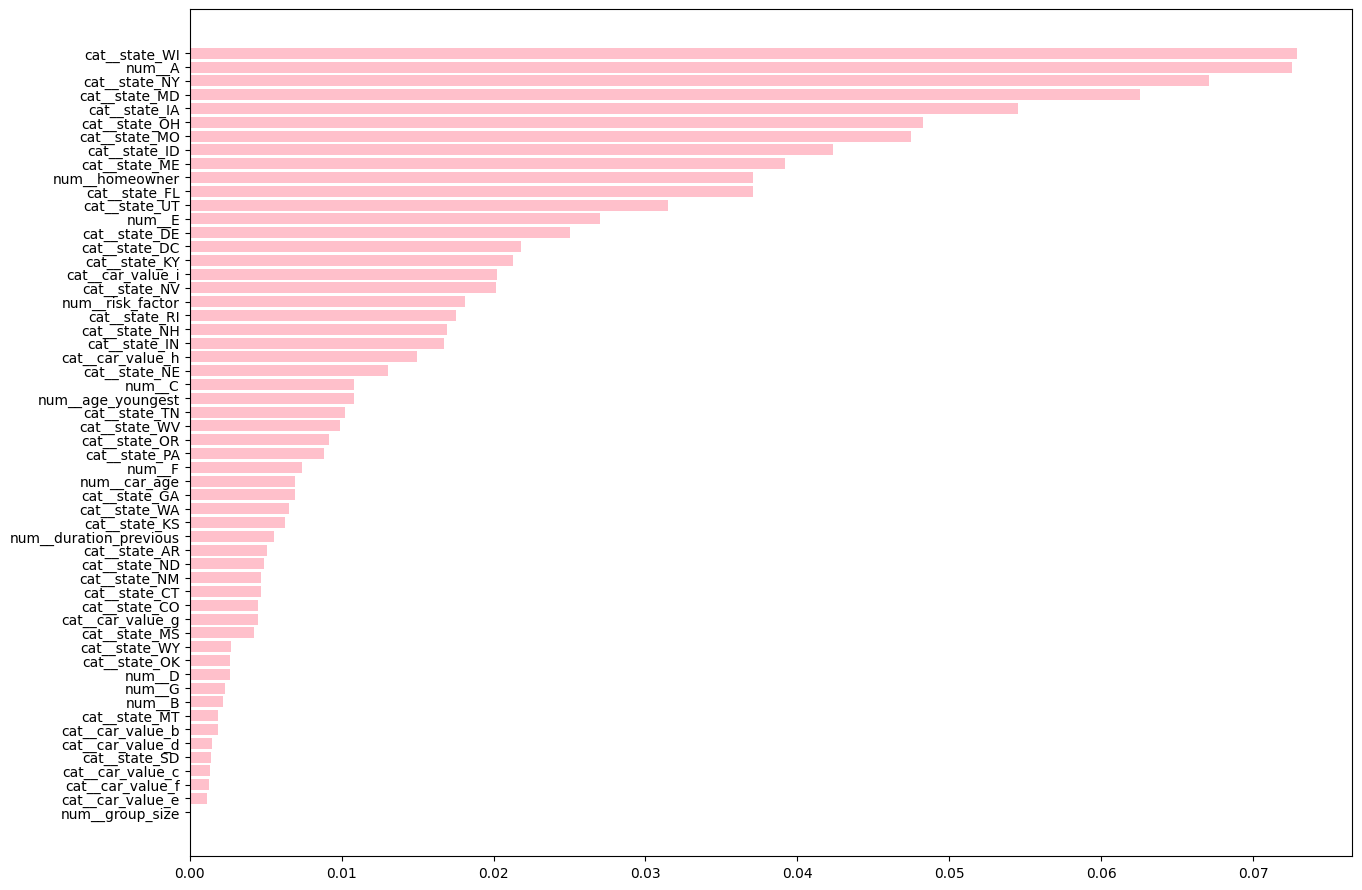

In [ ]:
importances = xgb_model.named_steps['regressor'].feature_importances_
feature_names = xgb_model.named_steps['preprocessing'].get_feature_names_out()
importances_df = pd.DataFrame({'Features': feature_names,
                                'Importances': importances }).sort_values('Importances',ascending = True)
plt.figure(figsize = (15,11))
plt.barh(importances_df['Features'],importances_df['Importances'],color = 'pink')